In [21]:
import pandas as pd
import numpy as np

In [22]:
# =====================================================
# Load Train-Test Dataset (CSV)
# =====================================================



# Load feature matrices
X_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_train.csv")
X_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_test.csv")

# Load target variables
y_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_train.csv").squeeze()
y_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_test.csv").squeeze()

print("Train/Test Shapes")
print("-" * 30)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nX_train Preview")
display(X_train.head())

print("\nX_test Preview")
display(X_test.head())

print("\ny_train Preview")
display(y_train.head())

print("\ny_test Preview")
display(y_test.head())

Train/Test Shapes
------------------------------
X_train: (692, 34)
X_test : (174, 34)
y_train: (692,)
y_test : (174,)

X_train Preview


,Year,Company,Stage_Level_CO2e_Available,Product_Weight,Industry_Automobiles,Industry_Beverages,Industry_Chemicals,Industry_Commercial Services & Supplies,Industry_Computers & Peripherals,Industry_Containers & Packaging,...,PCF_Protocol_Other,PCF_Protocol_PAS2050,PCF_Protocol_TRACI 2.1,Region_East Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America,Region_South Asia,Region_Southeast Asia
0,2015,15951.431092,0.0,6.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2014,15075.895807,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2014,15968.350188,0.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2013,16489.317365,0.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2016,10365.445532,0.0,99.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



X_test Preview


,Year,Company,Stage_Level_CO2e_Available,Product_Weight,Industry_Automobiles,Industry_Beverages,Industry_Chemicals,Industry_Commercial Services & Supplies,Industry_Computers & Peripherals,Industry_Containers & Packaging,...,PCF_Protocol_Other,PCF_Protocol_PAS2050,PCF_Protocol_TRACI 2.1,Region_East Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America,Region_South Asia,Region_Southeast Asia
0,2017,14134.466016,0.0,26.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013,14615.861638,0.0,11.200,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2017,9476.191838,0.0,20.000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2016,15968.950368,0.0,1000.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2015,9402.086088,0.0,0.997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



y_train Preview


0     409.00
1      26.00
2     554.94
3    1102.00
4      76.00
Name: PCF, dtype: float64


y_test Preview


0    2300.0
1     580.0
2      58.0
3    2219.0
4      15.0
Name: PCF, dtype: float64

In [23]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import  scipy

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

StandardScaler is applied only to the continuous numerical features
(Company and Product_Weight) as value are not in range. Linear models are sensitive to feature
scale, whereas one-hot encoded binary features do not require scaling.



After one-hot encoding, you'll have around 60–80 features (depending on the categories).

Your dataset has 866 samples.

This is not a high-dimensional dataset. PCA is generally more useful when you have hundreds or thousands of correlated numerical features (e.g., images, gene expression data, text embeddings). With your structured tabular data, PCA may:

reduce interpretability,
mix one-hot encoded categorical features into principal components,
make it harder to explain the model in your dissertation,
and may not improve prediction performance.

Most tree-based models you're planning to use (Random Forest, XGBoost, CatBoost) do not benefit from PCA.

In [24]:

# Model Performance Table
# =====================================================

results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2_Original",
        "R2_Log"
    ]
)

In [31]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Company",
    "Product_Weight"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train_scaled[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test_scaled[numeric_features]
)


# Model 1 : Linear Regression

In [32]:

# Model 1 : Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression


In [33]:
# Initialize model
lr = LinearRegression()

# Train using log-transformed target
lr.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 2400.14,188924.76, 0. ,..., 9155.25, 20886.64, 16446.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['Year','Company','Stage_Level_CO2e_Available',...,'Region_South America', 'Region_South Asia','Region_Southeast Asia']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.876e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(33)


In [28]:
# Prediction on log scale
y_pred_log = lr.predict(
    X_test_scaled
)

# Convert predictions back to original PCF scale
y_pred = np.expm1(
    y_pred_log
)

/tmp/ipykernel_3566/1762057674.py:7: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(


In [29]:


print("y_test")
print("NaN:", np.isnan(y_test).sum())
print("Inf:", np.isinf(y_test).sum())
print("Max:", np.max(y_test))

print("\ny_pred_log")
print("NaN:", np.isnan(y_pred_log).sum())
print("Inf:", np.isinf(y_pred_log).sum())
print("Max:", np.max(y_pred_log))

print("\ny_pred")
print("NaN:", np.isnan(y_pred).sum())
print("Inf:", np.isinf(y_pred).sum())
print("Max:", np.max(y_pred))

y_test
NaN: 0
Inf: 0
Max: 99075.0

y_pred_log
NaN: 0
Inf: 0
Max: 114044.38597870339

y_pred
NaN: 0
Inf: 95
Max: inf


In [30]:
# Original scale metrics

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

# Log-scale R²

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

ValueError: Input contains infinity or a value too large for dtype('float64').

In [10]:
print("=" * 60)
print("Linear Regression (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Baseline)
MAE (Original Scale)       : 26,910.97
RMSE (Original Scale)      : 298,528.55
R² (Original Scale)        : -586.3506
R² (Log-transformed Scale) : 0.6335


In [11]:
results.loc[len(results)] = [
    "Linear Regression",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542


In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train_log,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-Validation R² Scores: [0.76558579 0.70125831 0.64309447 0.66940996 0.74341736]
Mean CV R²: 0.7045531786128423
Std Dev: 0.045295650805295684


In [13]:
lr.fit(
    X_train_scaled,
    y_train_log
)

LinearRegression()

In [14]:
y_pred_log = lr.predict(X_test_scaled)

In [15]:
y_pred_log

array([ 5.04099414,  5.96057054,  3.29255604,  7.59767419,  2.81703796,
        3.07407106,  3.84350793,  7.15190971,  6.05980489,  6.48946252,
        6.25897523,  7.18085601,  3.56700938,  9.82824524,  5.13138986,
        6.36384231,  7.49070156,  3.34569633, -0.22260819,  4.63058921,
        1.34812424,  8.91112616,  3.6800038 ,  8.77939837,  7.25394153,
        3.83240597,  5.24753285,  6.70621303,  3.69439082,  3.56700938,
        2.62941967,  4.6357761 ,  2.32161211, 11.65430009,  2.93574683,
        4.69280269,  7.59767419,  7.18085601,  5.52361733,  7.27414435,
        0.46680905,  2.00709621,  2.68736822,  4.97122859,  0.37171516,
        2.00709621,  6.17684372,  4.16169182,  6.31074989,  3.259632  ,
        4.82345054,  1.61762994,  4.65785393,  4.93015605,  4.85452543,
        4.56005533,  0.129166  ,  2.88281925,  5.45291082,  4.75501013,
        3.571937  ,  5.0572015 ,  3.25657547,  2.60766317,  4.65785393,
        6.8901346 ,  4.84652063,  1.01140366,  3.70674343,  5.68

In [16]:
# Convert predictions back to original PCF scale
y_pred = np.expm1(
    y_pred_log
)
y_pred


array([ 1.53623656e+02,  3.86831333e+02,  2.59115629e+01,  1.99255388e+03,
        1.57272304e+01,  2.06297798e+01,  4.56889690e+01,  1.27554145e+03,
        4.27291866e+02,  6.57169513e+02,  5.21683037e+02,  1.31303260e+03,
        3.44105351e+01,  1.85493742e+04,  1.68252192e+02,  5.79472433e+02,
        1.79030836e+03,  2.73803309e+01, -1.99571595e-01,  1.01574484e+02,
        2.85019670e+00,  7.41300572e+03,  3.86465446e+01,  6.49796602e+03,
        1.41266588e+03,  4.51734966e+01,  1.89096692e+02,  8.16469041e+02,
        3.92210632e+01,  3.44105351e+01,  1.28657209e+01,  1.02107909e+02,
        9.19209186e+00,  1.15184608e+05,  1.78355649e+01,  1.08158689e+02,
        1.99255388e+03,  1.31303260e+03,  2.49539685e+02,  1.44151638e+03,
        5.94896828e-01,  6.44167691e+00,  1.36929564e+01,  1.43203947e+02,
        4.50219837e-01,  6.44167691e+00,  4.80469902e+02,  6.31800117e+01,
        5.49457575e+02,  2.50399528e+01,  1.23393576e+02,  4.04112837e+00,
        1.04409622e+02,  

In [17]:
score = lr.score(X_test, y_test)
score

0.1319029775281204

In [18]:
# Original scale metrics

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

# Log-scale R²

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [19]:
print("=" * 60)
print("Linear Regression (Cross Validation)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Cross Validation)
MAE (Original Scale)       : 26,910.97
RMSE (Original Scale)      : 298,528.55
R² (Original Scale)        : -586.3506
R² (Log-transformed Scale) : 0.6335


#### Here is the explanation of LR baseline Model ( Click the Details Button to see more)

<details>
These are exactly the kinds of questions an MSc supervisor or teammate would ask. Let's answer them one by one.

**1. "Why is R² (Original) and R² (Log) so different?"**

This is a perfectly valid question, and you should be able to explain it.

**Simple explanation**

Your target variable (**PCF**) is **highly right-skewed**.

Before transformation:

* Skewness = **15.77**

After `log1p()`:

* Skewness = **0.22**

Because of this, you trained the model on the transformed target.

The model therefore learns:

[
\log(PCF + 1)
]

instead of

[
PCF
]

After prediction, you convert back using:

[
PCF = e^{prediction}-1
]

The exponential function amplifies prediction errors, especially for products with very large carbon footprints.

For example:

| Actual Log | Predicted Log |
| ---------- | ------------- |
| 11.5       | 15.2          |

Difference = **3.7**

Looks acceptable.

After inverse transformation:

| Actual | Predicted |
| -----: | --------: |
| 99,075 | 4,023,285 |

Now the error is enormous.

RMSE squares that error.

Therefore

* Log R² remains good.
* Original R² becomes very poor.

This is **not a coding mistake**.

It is a mathematical consequence of inverse log transformation.



**How to write this in the dissertation**

You can write something like this:

> The target variable (PCF) exhibited substantial positive skewness (15.77). To reduce skewness and stabilize variance, a logarithmic transformation (`log1p`) was applied prior to model training, reducing the skewness to 0.22. Model performance was therefore evaluated on both the transformed and original scales. Although Linear Regression achieved satisfactory performance on the transformed target (R² = 0.634), inverse transformation amplified prediction errors for several high-emission products due to the exponential nature of the transformation. Consequently, performance on the original PCF scale deteriorated considerably. This finding highlights the limitations of Linear Regression for modeling highly skewed carbon footprint data.

That is an academically sound explanation.



 **2. Can we tune Linear Regression?**

Almost **no**.

Linear Regression has essentially no meaningful hyperparameters.

```python
LinearRegression()
```

Main parameters include:

```text
fit_intercept
copy_X
positive
tol
```

These are implementation options rather than optimization parameters.

So there is **no GridSearchCV** or **RandomizedSearchCV** worth performing for ordinary Linear Regression.

In your dissertation, treat it as the **baseline model**.



**3. Should we tune Ridge and Lasso?**

**Yes.**

Typical tuning parameters are:

####Ridge

```python
alpha
solver
```

####Lasso

```python
alpha
max_iter
```

These models benefit from hyperparameter tuning.


**4. Are our selected features good?**

Let's review them.

| Feature                    | Why it was selected                        |
| -------------------------- | ------------------------------------------ |
| Year                       | Captures temporal variation                |
| Company (Target Encoding)  | Company-specific emission patterns         |
| Stage_Level_CO2e_Available | Indicates reporting completeness           |
| Product_Weight             | Strong physical driver of emissions        |
| Industry                   | Sector-specific production characteristics |
| Region                     | Geographic variation                       |
| PCF_Protocol               | Differences in calculation methodology     |

This is a sensible feature set.



** Could we add more?**

Yes, if the dataset contained useful additional predictors.

However, you intentionally removed variables like:

* Product Name
* Product Detail
* PCF-ID

because they are identifiers or high-cardinality text that are not appropriate for this baseline tabular model.

That is a defensible decision.



** 5. Will Linear Regression always perform poorly?**

Probably.

Your dataset characteristics are:

* Highly skewed target.
* Nonlinear relationships.
* Mixed numeric and categorical variables.
* Large variance in emissions.

Linear Regression assumes:

* Linear relationships.
* Constant variance.
* Normally distributed residuals (for inference).

Those assumptions are only partially satisfied here.



**6. What do I expect next?**

Something like:

| Model             | Expected Performance       |
| ----------------- | -------------------------- |
| Linear Regression | Baseline                   |
| Ridge             | Slightly better            |
| Lasso             | Similar or slightly better |
| Decision Tree     | Better                     |
| Random Forest     | Much better                |
| Gradient Boosting | Better                     |
| XGBoost           | Excellent                  |
| Extra Trees       | Excellent                  |
| CatBoost          | Excellent                  |

The tree-based models should reduce the large errors on high-PCF products because they can model nonlinear relationships without relying on a single global linear equation.


</details>

In [20]:
comparison = pd.DataFrame({
    "Actual_PCF": y_test,
    "Predicted_PCF": y_pred
})

comparison["Absolute_Error"] = (
    comparison["Actual_PCF"] -
    comparison["Predicted_PCF"]
).abs()

comparison.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

,Actual_PCF,Predicted_PCF,Absolute_Error
138,99075.0,4.023285e+06,3.924210e+06
158,38000.0,3.489229e+05,3.109229e+05
118,28011.0,8.470667e+04,5.669567e+04
141,24000.0,6.509758e+04,4.109758e+04
163,34000.0,2.376806e+03,3.162319e+04
33,85000.0,1.151846e+05,3.018461e+04
170,31000.0,2.376806e+03,2.862319e+04
23,33683.0,6.497966e+03,2.718503e+04
101,32500.0,1.011665e+04,2.238335e+04
85,34694.0,1.656402e+04,1.812998e+04


#model: Ridge Regression

In [21]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [22]:
ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [23]:
ridge.fit(
    X_train_scaled,
    y_train_log
)

Ridge(random_state=42)

In [24]:
y_pred_log = ridge.predict(
    X_test_scaled
)

y_pred = np.expm1(
    y_pred_log
)

In [25]:
score = ridge.score(X_test, y_test_log)
score

-558070.1820098053

In [26]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [27]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
MAE (Original Scale)       : 25,143.44
RMSE (Original Scale)      : 270,464.59
R² (Original Scale)        : -481.1104
R² (Log-transformed Scale) : 0.6423


In [28]:
results.loc[len(results)] = [
    "Ridge Regression",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_log)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'alpha': 1}
Best CV Score : 0.7052247497060384


In [30]:
best_ridge = grid.best_estimator_

In [31]:
y_pred_log = best_ridge.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [32]:
score = best_ridge.score(X_test, y_test_log)
score

-558070.1820098053

In [33]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [34]:
results.loc[len(results)] = [
    "Ridge Regression (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319


Model to be work with: Support Vector Regression (SVR)

K-Nearest Neighbors (KNN)

Version 2 – Unscaled Dataset
Use this version for tree-based models, including:

Random Forest

XGBoost

LightGBM

CatBoost

Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor



In [36]:
rf = RandomForestRegressor(
    random_state=42
)

In [37]:
rf.fit(
    X_train,
    y_train_log
)

RandomForestRegressor(random_state=42)

In [38]:
rf.fit(
    X_train,
    y_train_log
)

RandomForestRegressor(random_state=42)

In [39]:
y_pred_log = rf.predict(
    X_test_scaled
)

In [40]:
y_pred = np.expm1(
    y_pred_log
)
y_pred

array([ 1.7306452 ,  1.27748852,  0.72839949,  6.27675331,  0.74041502,
        1.60868349,  0.91293724,  0.95349083,  3.70988581,  1.45938858,
        1.11649109,  2.75001147,  0.75839121, 36.50693635,  2.46276616,
        2.87326795,  9.2444923 ,  0.73174424,  0.45111409,  1.55232592,
        0.5537388 ,  0.8803533 ,  1.42722604, 47.07095808,  2.61613714,
        1.70721091,  1.43924791,  2.80186215,  0.78343191,  0.75839121,
        0.78455064,  3.31739709,  0.59584859, 35.67694673,  0.92267899,
        1.53479914,  6.27675331,  2.75001147,  1.6903233 ,  7.65856509,
        0.45445546,  0.33701317,  0.56410317,  0.62514424,  0.37820917,
        0.33701317,  1.21519899,  1.42680747,  0.66338707,  0.95050411,
        0.62514424,  0.62175457,  1.39667715,  0.62514424,  0.62514424,
        1.08052929,  0.42210299,  1.24640972,  1.77480245,  1.39667715,
        0.75839121,  1.61064855,  2.29723936,  0.77691825,  1.39667715,
        9.975679  ,  0.62514424,  0.57412511,  1.42926501, 10.11

In [41]:
score = rf.score(X_test, y_test)
score

-0.10398312572311741

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4,6]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.9265297811430827


In [43]:
best_rf = grid.best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [44]:
score = best_rf.score(X_test, y_test_log)

print(score)

0.9455218605890959


In [45]:
from sklearn.metrics import r2_score

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

print(f"Test R² (Original Scale): {r2_original:.4f}")
print(f"Test R² (Log Scale): {r2_log:.4f}")
print("Variance Explained:", r2_original * 100, "%")

Test R² (Original Scale): 0.5535
Test R² (Log Scale): 0.9455
Variance Explained: 55.35172413395415 %


In [46]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                              Feature  Importance
3                                      Product_Weight    0.724319
1                                             Company    0.178019
5                                  Industry_Beverages    0.014741
2                          Stage_Level_CO2e_Available    0.008380
8                    Industry_Computers & Peripherals    0.007890
0                                                Year    0.007206
7             Industry_Commercial Services & Supplies    0.007085
22                                   PCF_Protocol_ISO    0.006487
28                                      Region_Europe    0.004695
26                             PCF_Protocol_TRACI 2.1    0.004639
27                                   Region_East Asia    0.004266
23                          PCF_Protocol_Not reported    0.003446
29                               Region_North America    0.003252
18                                     Industry_Other    0.003093
6         

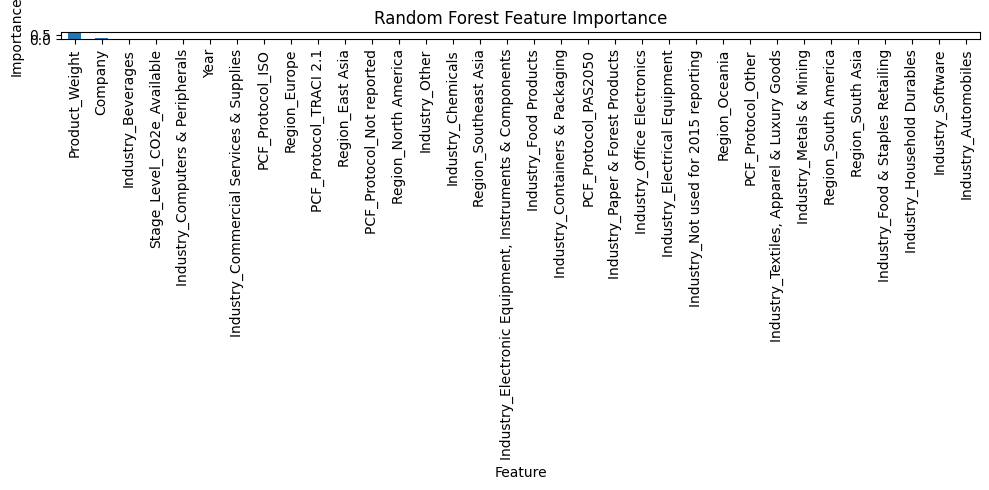

In [47]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,    # Test 30 random combinations
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Score: 0.9171496252884884


In [49]:
best_rf = random_search . best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [50]:
score = best_rf.score(X_test, y_test_log)

print(f"score:{score}")

score:0.8848000398765796


In [51]:


r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

print(f"Test R² (Original Scale): {r2_original:.4f}")
print(f"Test R² (Log Scale): {r2_log:.4f}")
print("Variance Explained:", r2_original * 100, "%")

Test R² (Original Scale): 0.5192
Test R² (Log Scale): 0.8848
Variance Explained: 51.92269497390378 %


# XG Boost


In [52]:
from xgboost import XGBRegressor



In [53]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [54]:
xgb.fit(
    X_train,
    y_train_log
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
y_pred_log = xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [56]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [57]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1831.68
RMSE (Original Scale)      : 8500.18
R² (Original Scale)        : 0.5238
R² (Log-transformed Scale) : 0.9331


In [58]:
results.loc[len(results)] = [
    "XGBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068


In [59]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV Score: 0.932951849225986


In [60]:
best_xgb = random_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [61]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_original = r2_score(y_test, y_pred)
r2_log = r2_score(y_test_log, y_pred_log)


In [62]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1928.30
RMSE (Original Scale)      : 8745.53
R² (Original Scale)        : 0.4959
R² (Log-transformed Scale) : 0.9328


In [63]:

results.loc[len(results)] = [
    "XGBoost (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]

In [64]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [65]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [66]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [67]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [68]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Best CV Score:
0.9346951346007645


In [69]:
best_xgb = grid.best_estimator_
y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [70]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [71]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1924.84
RMSE (Original Scale)      : 8445.93
R² (Original Scale)        : 0.5299
R² (Log-transformed Scale) : 0.9392


In [72]:
results.loc[len(results)] = [
    "XGBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068
4,XGBoost (Tuned),1928.304586,8745.529151,0.495922,0.932847
5,XGBoost (GridSearchCV),1924.840394,8445.930844,0.529867,0.939172


# CAT Boost

In [73]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [74]:
from catboost import CatBoostRegressor


In [75]:
cat = CatBoostRegressor(
    random_seed=42,
    verbose=0
)

In [76]:
cat.fit(
    X_train,
    y_train_log
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)

In [77]:
y_pred_log = cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [78]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [79]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 1995.96
RMSE (Original Scale)      : 8677.62
R² (Original Scale)        : 0.5037
R² (Log-transformed Scale) : 0.9038


In [80]:
results.loc[len(results)] = [
    "CatBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068
4,XGBoost (Tuned),1928.304586,8745.529151,0.495922,0.932847
5,XGBoost (GridSearchCV),1924.840394,8445.930844,0.529867,0.939172
6,CatBoost (Baseline),1995.960100,8677.622818,0.503720,0.903843


In [81]:


param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}
Best CV Score: 0.9361456912448716


In [82]:
best_cat = grid.best_estimator_

y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [83]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [84]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 2046.13
RMSE (Original Scale)      : 8730.34
R² (Original Scale)        : 0.4977
R² (Log-transformed Scale) : 0.8931


In [85]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
results.loc[len(results)] = [
    "CatBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
param_dist = {
    "iterations": [100, 200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.8, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

In [ ]:
best_cat = random_search.best_estimator_

In [ ]:
y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (RandomizedSearchCV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "CatBoost (RandomizedSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

# SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
svr = SVR()

svr.fit(X_train_scaled, y_train_log)

In [ ]:
y_pred_log = svr.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

print("="*60)
print("SVR (Baseline)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR Base Linee",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:


param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_svr_grid = grid.best_estimator_

y_pred_log = best_svr_grid.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (GridSearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:


param_dist = {
    "C": [0.1, 1, 10, 50, 100, 500],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear", "poly"]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
best_svr_random = random_search.best_estimator_

y_pred_log = best_svr_random.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (Randomsearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Randomsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results